In [1]:
import sys
import os
import jax
import jax.numpy as np
import jax.tree as jtu
import jax.random as jr
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Basic jax import
jax.config.update("jax_enable_x64", True)


# Check if running on remote, and set directory to where notebook is run
if jax.devices()[0].platform == "gpu":
    os.chdir("code/amigo_project/notebooks/calibration")

# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ['..', "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)
        
# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 120

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)


def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)

In [2]:
def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)


# Add extra bad pixels
def add_badpix(file):
    file["BADPIX"].data[:1, :] = 1
    file["BADPIX"].data[-1:, :] = 1
    file["BADPIX"].data[:, :1] = 1
    file["BADPIX"].data[:, -1:] = 1
    file["BADPIX"].data[41:43, 1] = 1
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[43, 0] = 1
    file["BADPIX"].data[44, 70] = 1
    file["BADPIX"].data[4, 45] = 1
    file["BADPIX"].data[58, 14] = 1
    file["BADPIX"].data[61, 54] = 1
    file["BADPIX"].data[51, 27] = 1
    return file

In [3]:
from amigo.files import get_files

# data_path = "../../data/calslope"
data_path = "/Volumes/morgana1/snert/max/data/JWST/WR137/calslope/"
files = [add_badpix(f) for f in get_files(data_path, "nis_calslope")]

# Log Amplitudes and phases

In [4]:
from amigo.optical_models import AMIOptics

state = np.load(
    "/Volumes/morgana1/snert/max/data/amigo_files/models/cal_model.npy",
    allow_pickle=True,
).item()
aberrations = state["aberrations"]
defocus = state["defocus"]
optics = AMIOptics()

In [ ]:
from amigo.misc import tqdm
from amigo.vis_models import model_vis_psf
from amigo.stats import batched_jacobian, decompose
import dLux.utils as dlu

n_terms = 250
eig_mats = {"amplitude": {}, "phase": {}}
for filt in ["F380M", "F430M", "F480M"]:
    # n_knots = 51
    # n_pts = (n_knots**2) // 2
    # amp, phase = np.zeros((2, n_pts))
    # # abb = aberrations[filt]
    # abb = aberrations
    # defoc = defocus[filt]

    # output_fn = lambda x: dlu.downsample(x, 3, mean=False).flatten()
    # vis_fn = lambda amp, phase: output_fn(
    #     model_vis_psf(optics, amp, phase, filt, abb, defoc, n_knots)
    # )
    # J_amp = batched_jacobian(amp, lambda X: vis_fn(X, phase), n_batch=10)
    # J_phase = batched_jacobian(phase, lambda X: vis_fn(amp, X), n_batch=10)

    n_knots = 51
    n_pts = (n_knots**2) - 1  # dont control the DC term
    vis_vec = np.zeros(n_pts)
    abb = aberrations  # [filt]
    defoc = defocus[filt]

    #
    output_fn = lambda x: dlu.downsample(x, 3, mean=False).flatten()
    vis_fn = lambda vis_vec: output_fn(
        model_vis_psf(optics, vis_vec, filt, abb, defoc, n_knots)
    )
    psf = vis_fn(vis_vec)

    # Amplitudes
    J = batched_jacobian(vis_vec, lambda X: vis_fn(X), n_batch=30)
    J_amp, J_phase = np.split(J, 2, axis=0)
    # H_amp, eig_vals_amp, eig_vecs_amp = decompose(J_amp, psf)
    # H_phase, eig_vals_phase, eig_vecs_phase = decompose(J_phase, psf)

    # Phases
    H_amp, amp_vals, amp_vecs = decompose(J_amp, psf)
    H_phase, phase_vals, phase_vecs = decompose(J_phase, psf)
    eig_mats["amplitude"][filt] = amp_vecs
    eig_mats["phase"][filt] = phase_vecs

    plt.figure(figsize=(10, 4))
    plt.suptitle(f"{filt} Hessian")

    plt.subplot(1, 2, 1)
    plt.title("Amplitude")
    plt.imshow(np.abs(H_amp) ** 0.1, cmap="inferno")
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.title("Phase")
    plt.imshow(np.abs(H_phase) ** 0.1, cmap="inferno")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.title(f"{filt} Eigenvalues")
    plt.plot(amp_vals, label="Amplitude")
    plt.plot(phase_vals, label="Phase")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

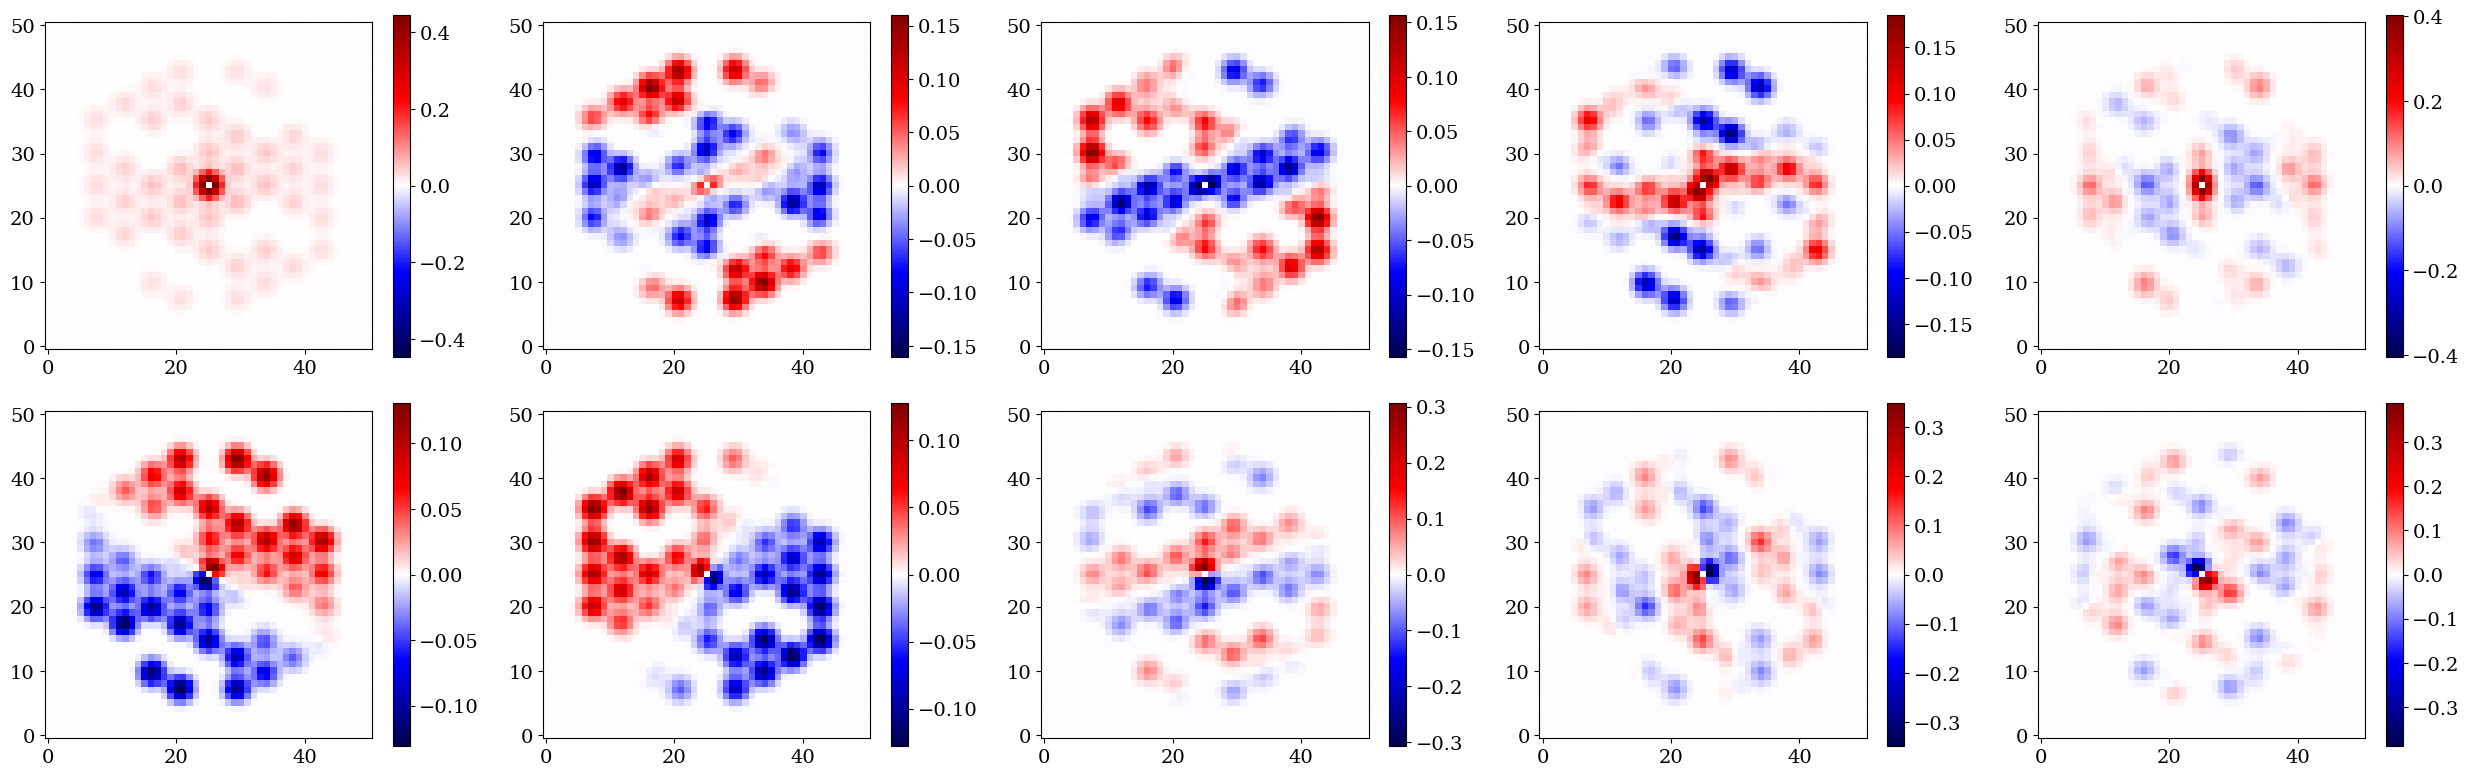

In [ ]:
from amigo.vis_models import vis_to_im

plt.figure(figsize=(25, 8))
for i in range(5):
    log_amp, phase = vis_to_im(amp_vecs[i], phase_vecs[i], (51, 51))

    v = np.nanmax(np.abs(log_amp))
    plt.subplot(2, 5, i + 1)
    plt.imshow(log_amp, seismic, vmin=-v, vmax=v)
    plt.colorbar()

    v = np.nanmax(np.abs(phase))
    plt.subplot(2, 5, i + 6)
    plt.imshow(phase, seismic, vmin=-v, vmax=v)
    plt.colorbar()

plt.tight_layout()
plt.show()

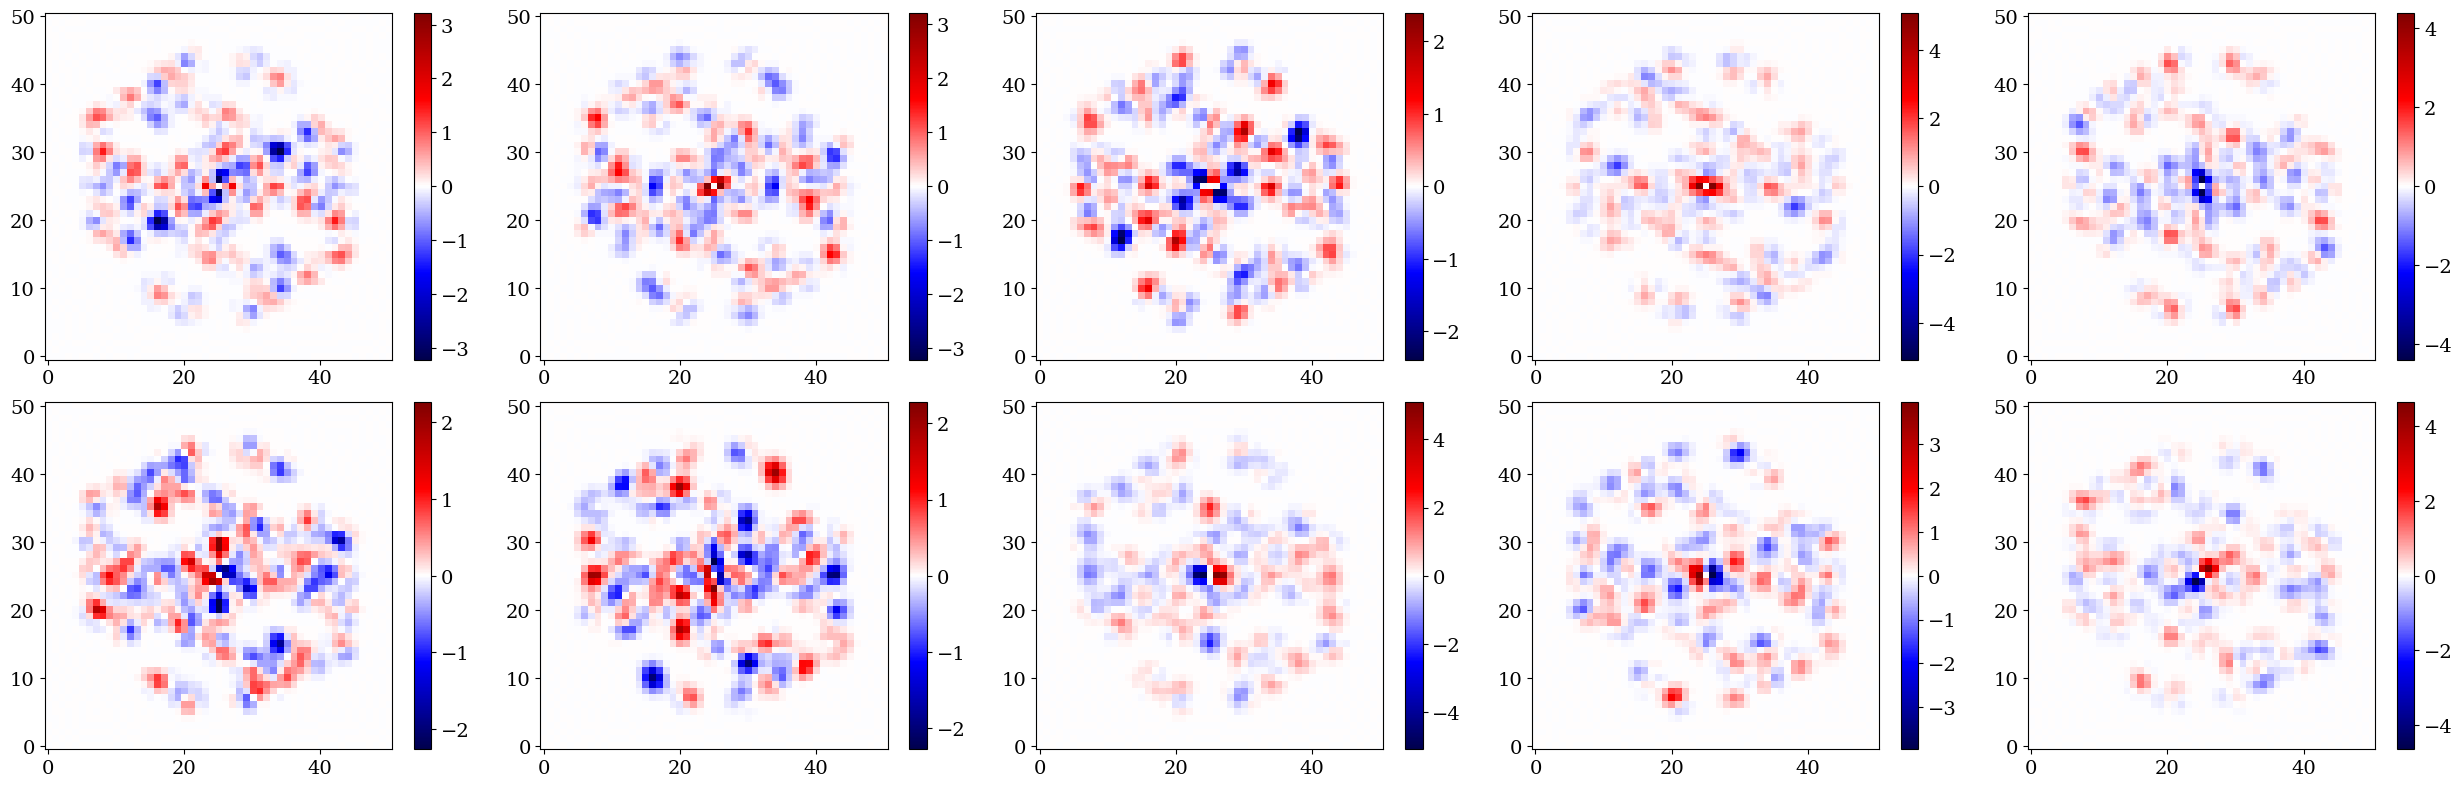

In [ ]:
# n_basis = 150

# plt.figure(figsize=(25, 8))
# for i in range(5):
#     latent_amp, latent_phase = jr.normal(jr.key(i), (2, n_basis))
#     log_amp = np.dot(latent_amp, amp_vecs[:n_basis])
#     phase = np.dot(latent_phase, phase_vecs[:n_basis])
#     log_amp, phase = vis_to_im(log_amp, phase, (51, 51))

#     v = np.nanmax(np.abs(log_amp))
#     plt.subplot(2, 5, i + 1)
#     plt.imshow(log_amp, seismic, vmin=-v, vmax=v)
#     plt.colorbar()

#     v = np.nanmax(np.abs(phase))
#     plt.subplot(2, 5, i + 6)
#     plt.imshow(phase, seismic, vmin=-v, vmax=v)
#     plt.colorbar()

# plt.tight_layout()
# plt.show()

In [ ]:
from amigo.vis_models import LogVisModel

otf_coords = dlu.pixel_coords(51, 2 * optics.diameter)
vis_model = LogVisModel(
    eig_mats["amplitude"],
    eig_mats["phase"],
    otf_coords,
    n_terms=450,
)

In [ ]:
from amigo.ramp_models import DFRNN, RNNRamp
from amigo.detector_models import PixelSensitivity


ramp_model = RNNRamp(DFRNN(jr.key(0)), gain_model=PixelSensitivity(), norm=2**14)

In [ ]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import SUB80Detector
from amigo.read_models import ReadModel
from amigo.model_fits import SplineVisFit


# Get the model
exposures = [SplineVisFit(file) for file in files]
model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(static=True),
    detector=SUB80Detector(ramp_model=ramp_model),
    read=ReadModel(),
    vis_model=vis_model,
)

In [ ]:
state = np.load("../../GPU_files/results/cal_model.npy", allow_pickle=True).item()

for key, value in state.items():
    if key in ["aberrations"]:
        model = model.set("aberrations", jtu.map(lambda x: value, model.aberrations))
        continue
    model = model.set(key, value)

04481_F380M
04481_F430M
04481_F480M


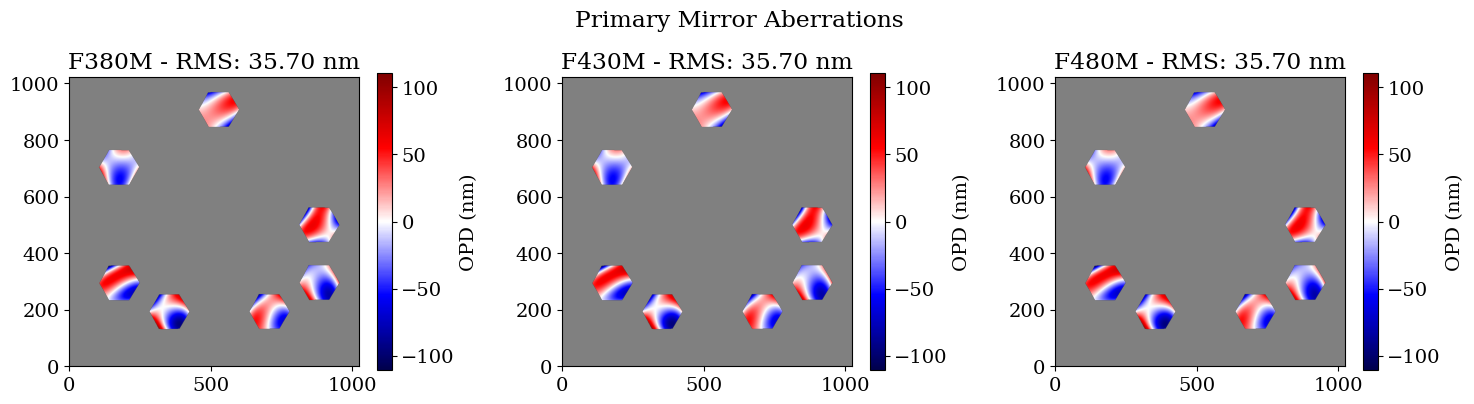

In [ ]:
cal_aberrations = {key: val for key, val in model.aberrations.items() if "04481" in key}

optics = model.optics
pupil_mask = model.optics.pupil_mask

plt.figure(figsize=(15, 4))
plt.suptitle("Primary Mirror Aberrations")
for i, key in enumerate(cal_aberrations):
    filt = key.split("_")[-1]
    print(key)

    coeffs = model.aberrations[key]
    full_abb = pupil_mask.set("abb_coeffs", coeffs).calc_aberrations()
    flat_abb = pupil_mask.set("abb_coeffs", coeffs.at[:, :3].set(0)).calc_aberrations()

    mask = pupil_mask.transmission

    full_abb = np.where(mask < 1.0, np.nan, 1e9 * full_abb)
    flat_abb = np.where(mask < 1.0, np.nan, 1e9 * flat_abb)

    full_abb -= np.nanmean(full_abb)
    flat_abb -= np.nanmean(flat_abb)

    rms = lambda x: np.sqrt(np.nanmean(np.square(x)))

    v = np.nanmax(np.abs(flat_abb))
    plt.subplot(1, 3, i + 1)
    plt.title(f"{filt} - RMS: {rms(flat_abb):.2f} nm")
    plt.imshow(flat_abb, cmap=seismic, vmin=-v, vmax=v)
    plt.colorbar(label="OPD (nm)")

plt.tight_layout()
plt.show()

In [ ]:
for exp in exposures:
    if exp.filter == "F430M":
        break

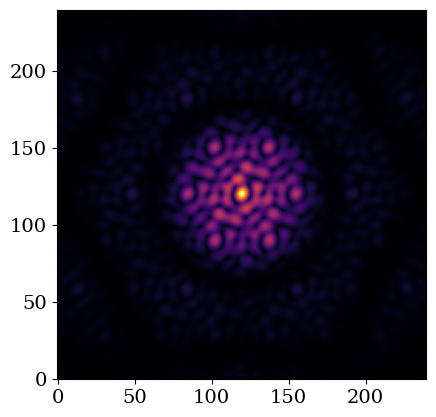

In [ ]:
model = model.set("positions", jtu.map(lambda x: 0 * x, model.positions))
psf = exp.model_psf(model)

plt.imshow(psf.data**0.5)

In [ ]:
vis_model

LogVisModel(
  V_amp={'F380M': f64[450,1300], 'F430M': f64[450,1300], 'F480M': f64[450,1300]},
  V_phase={
    'F380M':
    f64[450,1300],
    'F430M':
    f64[450,1300],
    'F480M':
    f64[450,1300]
  },
  otf_coords=f64[2,51,51],
  n_knots=51,
  n_terms=450
)

In [ ]:
from amigo.vis_models import wf_fft_coords, vis_to_im
from amigo.misc import interp
from jax import vmap

model = model.set("positions", jtu.map(lambda x: 0 * x, model.positions))
wfs = exp.model_wfs(model)

log_amps = np.zeros(model.vis_model.n_terms).at[:10].set(0.1)
phases = np.zeros(model.vis_model.n_terms).at[:10].set(0.1)

log_amps = np.dot(log_amps, vis_model.V_amp["F430M"])
phases = np.dot(phases, vis_model.V_phase["F430M"])
log_amps, phase = vis_to_im(log_amps, phases, otf_coords.shape[1:])

print(log_amps.shape, phases.shape)
print(otf_coords.shape)

# Interpolate the visibility maps to uv coordinates
uv_coords = wf_fft_coords(wfs, pad=2)
interp_fn = lambda im, uv: interp(im, otf_coords, uv, method="linear", fill=0.0)
log_amps = vmap(lambda uv: interp_fn(log_amps, uv))(uv_coords)
phases = vmap(lambda uv: interp_fn(phase, uv))(uv_coords)

# Fourier Functions (use 2x pad)
n = uv_coords.shape[-1] // 4
crop_fn = lambda x: x[n:-n, n:-n]
pad_fn = lambda x: np.pad(x, n, mode="constant")
to_uv = vmap(lambda x: np.fft.fftshift(np.fft.fft2(pad_fn(x))))
from_uv = vmap(lambda x: crop_fn(np.fft.ifft2(np.fft.ifftshift(x))))

# Apply the visibility maps
splodges = to_uv(wfs.psf)
# return np.abs(from_uv(splodges)).sum(0)

splodges.shape

(51, 51) (1300,)
(2, 51, 51)


(9, 480, 480)

In [ ]:
print(log_amps.shape, phases.shape)

(9, 480, 480) (9, 480, 480)


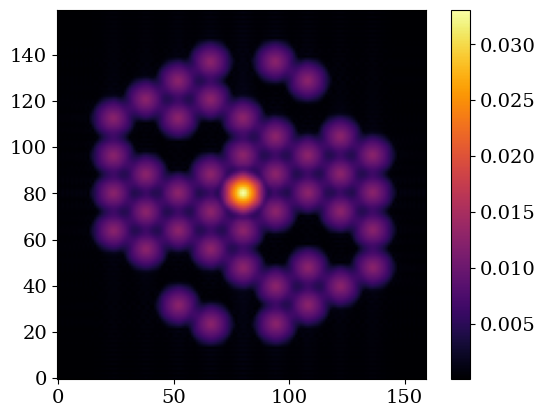

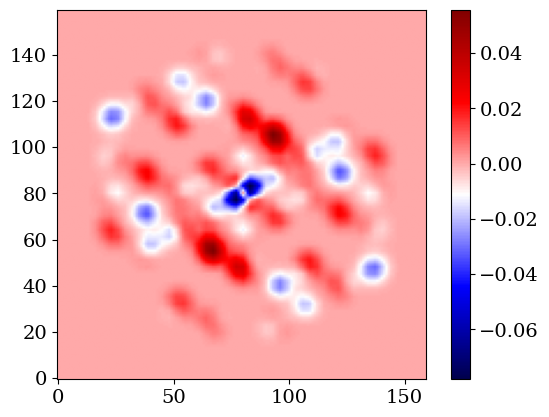

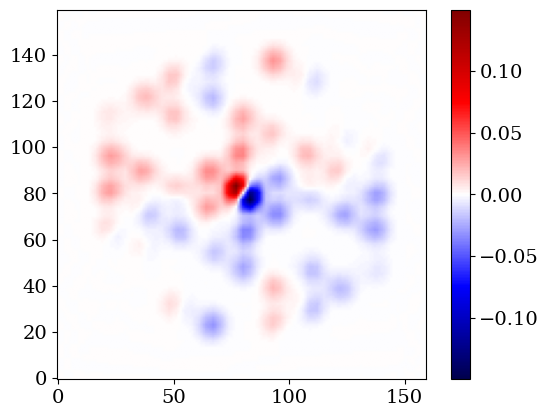

In [ ]:
splodge = splodges[0]
log_amp = log_amps[0]
phase = phases[0]


c = splodge.shape[0] // 2
s = 80

splodge = splodge[c - s : c + s, c - s : c + s]
log_amp = log_amp[c - s : c + s, c - s : c + s]
phase = phase[c - s : c + s, c - s : c + s]


plt.imshow(np.abs(splodge) ** 0.5)
plt.colorbar()
plt.show()


plt.imshow(log_amp, seismic)
plt.colorbar()
plt.show()


plt.imshow(phase, seismic)
plt.colorbar()
plt.show()